project code


In [ ]:
import pandas as pd

from IPython.display import display

print('--- STEP 1: LOAD & UNDERSTAND THE DATA ---')

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"

print("Loading dataset...\n")
df = pd.read_csv(url)


print("--- 1. DATASET SHAPE ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("--- 2. DATASET INFO ---")
df.info()
print("\n")

print("--- 3. SUMMARY STATISTICS ---")

display(df.describe())


print("\n--- 4. COLUMN VERIFICATION ---")
print("Here are all the columns currently in the dataset:\n", df.columns.tolist(), "\n")

# verify the specific columns you need for your project are present
expected_columns = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

print("Checking for your target features and failure types:")
actual_columns = df.columns.tolist()
for col in expected_columns:
    if col in actual_columns:
        print(f"Found: '{col}'")
    else:
        print(f" Missing: '{col}' (Check for typos or formatting differences)")

--- STEP 1: LOAD & UNDERSTAND THE DATA ---
Loading dataset...

--- 1. DATASET SHAPE ---
Total Rows: 10000
Total Columns: 14

--- 2. DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-n

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



--- 4. COLUMN VERIFICATION ---
Here are all the columns currently in the dataset:
 ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'] 

Checking for your target features and failure types:
Found: 'Air temperature [K]'
Found: 'Process temperature [K]'
Found: 'Rotational speed [rpm]'
Found: 'Torque [Nm]'
Found: 'Tool wear [min]'
Found: 'Machine failure'
Found: 'TWF'
Found: 'HDF'
Found: 'PWF'
Found: 'OSF'
Found: 'RNF'


In [ ]:
print('--- STEP 2: DATA CLEANING ---')

print('\nChecking for missing values:')
display(df.isnull().sum().to_frame(name='Missing Values'))

# Dropping irrelevant columns (UID and Product ID)
print('\nDropping UDI and Product ID columns...')
df = df.drop(columns=['UDI', 'Product ID'])
print('Columns after dropping:', df.columns.tolist())

print('\nVerifying data types after cleaning:')
df.info()

--- STEP 2: DATA CLEANING ---

Checking for missing values:


,Missing Values
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Dropping UDI and Product ID columns...
Columns after dropping: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Verifying data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF               

--- STEP 3: Exploratory Data Analysis   ---
Class Balance
Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


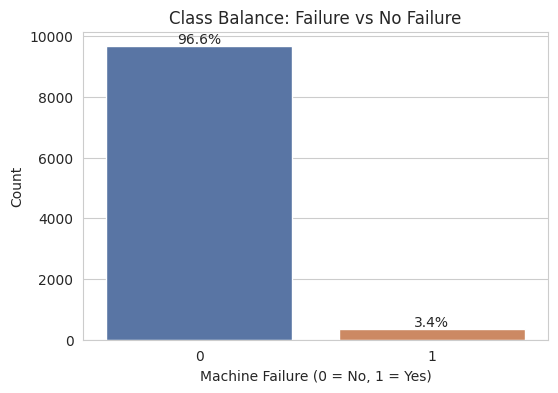

In [ ]:
print('--- STEP 3: Exploratory Data Analysis   ---')

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


#Class Balance - Machine Failure (0 = No Failure , 1 = Failure)
print("Class Balance")
failure_count = df["Machine failure"].value_counts()
failure_pct = df["Machine failure"].value_counts(normalize=True) * 100
print(failure_count)
print(failure_pct.round(2))

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Machine failure' , hue='Machine failure', data = df , palette = ['#4C72B0','#DD8452'] ,  legend=False)
plt.title('Class Balance: Failure vs No Failure')
plt.xlabel('Machine Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')

for p in ax.patches:
  pct = 100 * p.get_height() /len(df)
  ax.annotate(f'{pct:.1f}%' , (p.get_x() + p.get_width()/2 , p.get_height()) , ha = 'center' , va = "bottom")

plt.show()


The class distribution shows a significant imbalance in the dataset. Approximately 96.6% of the observations correspond to no machine failure (Class 0), while only 3.4% represent machine failure (Class 1). This indicates that machine failures are rare events, which is common in predictive maintenance datasets.

Such an imbalanced distribution may cause machine learning models to become biased toward predicting the majority class. Therefore, techniques such as SMOTE (Synthetic Minority Over-sampling Technique), class weighting, or resampling would be use to improve the model's ability to correctly identify failure cases.

Failure Type Breakdown
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


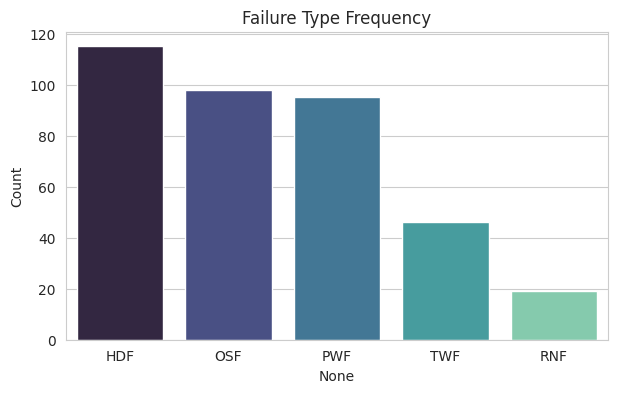

In [ ]:
#FAILURE TYPE BREAKDOWN (TWF, HDF, PWF, OSF, RNF)
print("Failure Type Breakdown")
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_type_counts = df[failure_types].sum().sort_values(ascending=False)
print(failure_type_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=failure_type_counts.index , y = failure_type_counts.values ,hue=failure_type_counts.index , palette= 'mako' , legend=False)
plt.title('Failure Type Frequency')
plt.ylabel('Count')
plt.show()



Feature Distribution


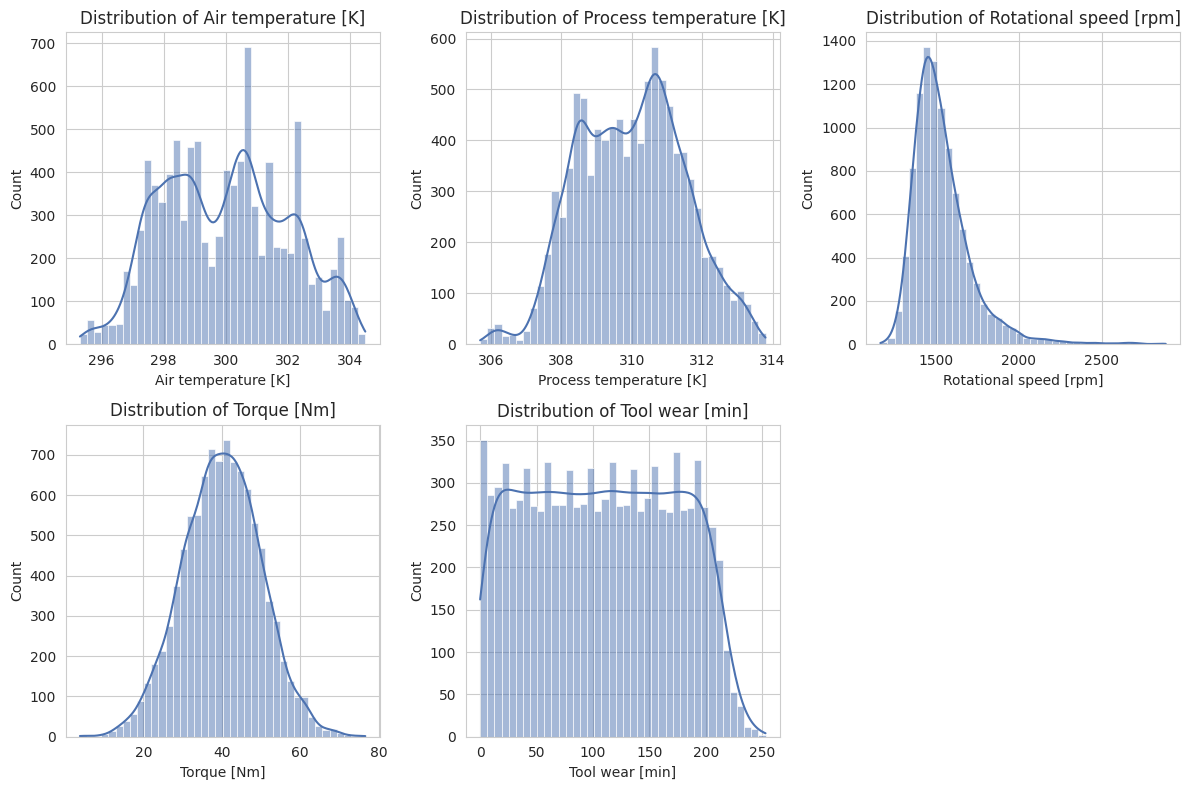

In [ ]:
# HISTOGRAMS — Torque, Temperatures, Speed, Tool wear

print("Feature Distribution")

numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
fig , axes = plt.subplots(2,3,figsize=(12,8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
  sns.histplot(df[col] , kde= True , ax = axes[i] , color ='#4C72B0', bins=40)
  axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

1. Air Temperature [K] :
The air temperature values range approximately from 295 K to 304 K.
The distribution is slightly multimodal, showing multiple small peaks instead of a single smooth peak, suggesting the data may have been collected under different operating conditions.
There are no significant outliers, and most observations lie between 298 K and 302 K.
2. Process Temperature [K]:
Process temperature ranges from approximately 306 K to 314 K.
The distribution is approximately bell-shaped (near normal) with a slight right skew.
Most observations are concentrated around 309–311 K, indicating a stable operating process.
3. Rotational Speed [rpm]:
The rotational speed distribution is positively (right) skewed.
Most machines operate between 1400 and 1600 rpm, while a small number operate at much higher speeds, creating a long right tail.
This indicates that high-speed operations are relatively rare.
4. Torque [Nm]:
Torque follows an approximately normal (Gaussian) distribution.
The highest concentration of values is around 40 Nm, with fewer observations at very low or very high torque values.
The distribution is fairly symmetric, suggesting consistent operating conditions.
5. Tool Wear [min]:
Tool wear is almost uniformly distributed between 0 and 200 minutes, meaning tools have been observed at nearly every wear level with similar frequency.
There is a sharp decline after 200 minutes, indicating very few tools exceed this wear limit.
This suggests the dataset intentionally includes tools across different stages of wear.



Feature Vs Failure


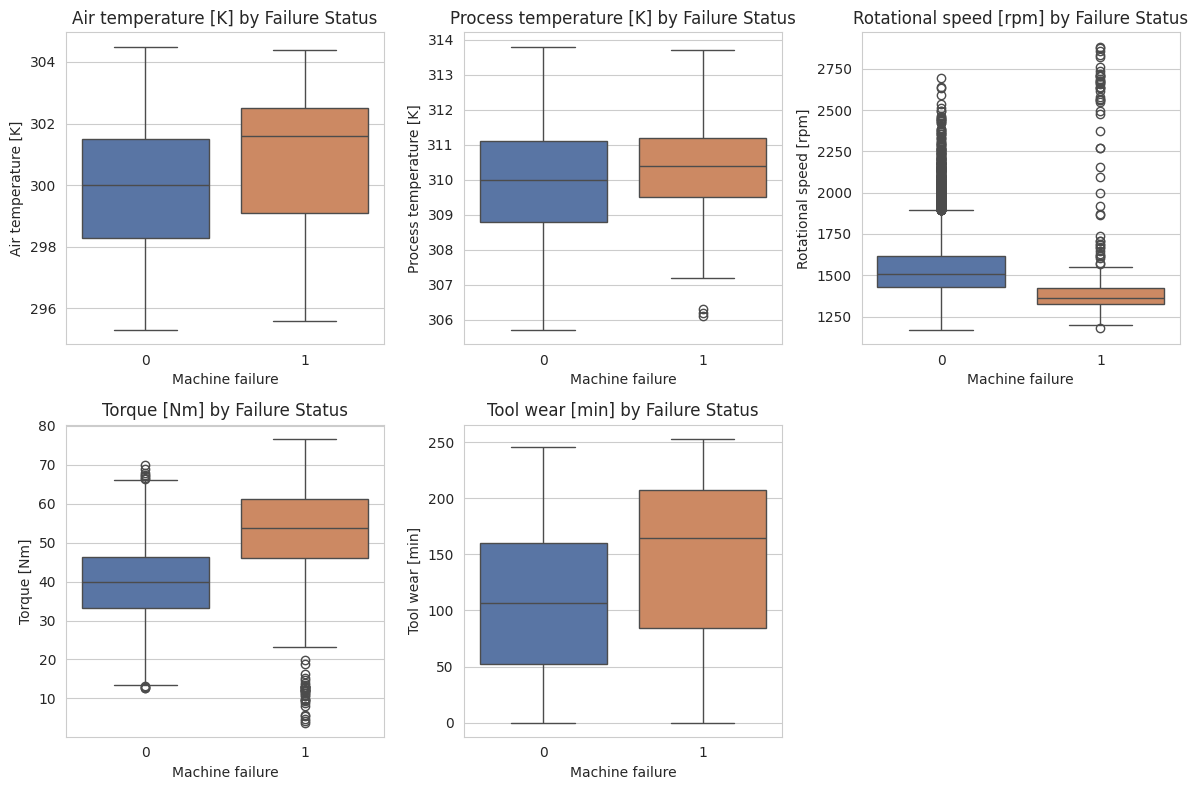

In [ ]:
#FEATURE DISTRIBUTIONS SPLIT BY FAILURE
print('Feature Vs Failure')
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i , col in enumerate(numeric_cols):
  sns.boxplot(x='Machine failure', y=col, data=df, hue ='Machine failure',  ax=axes[i], palette=['#4C72B0','#DD8452'] , legend=False)
  axes[i].set_title(f'{col} by Failure Status')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


1. Air Temperature vs Machine Failure :
Machines that experienced failure generally have a slightly higher air temperature than those that did not fail.
However, there is considerable overlap between the two groups, suggesting that air temperature alone is not a strong predictor of machine failure.
2. Process Temperature vs Machine Failure :
Failed machines have a slightly higher median process temperature compared to non-failed machines.
The overlap between the two distributions is still substantial, indicating that process temperature has some influence but is not sufficient by itself to distinguish failures.
3. Rotational Speed vs Machine Failure :
Machines with failures tend to operate at a lower median rotational speed than non-failed machines.
Both groups contain several high-speed outliers, but the difference in median values suggests that rotational speed may be an important feature for predicting failures.
4. Torque vs Machine Failure :
Failed machines exhibit a significantly higher median torque than non-failed machines.
The two distributions are more clearly separated than for the temperature features, indicating that higher torque is strongly associated with machine failures.
Although a few outliers exist, torque appears to be one of the most informative predictors.
5. Tool Wear vs Machine Failure :
Machines that failed generally have higher tool wear than those that did not.
The median tool wear is noticeably greater for failed machines, suggesting that increased wear contributes to a higher likelihood of failure.
However, some overlap indicates that failures can also occur at lower wear levels.



Overall Interpretation

The boxplots indicate that torque, tool wear, and rotational speed show the most noticeable differences between failed and non-failed machines, making them potentially strong predictors for machine failure. In contrast, air temperature and process temperature exhibit only small shifts in their distributions, suggesting they have a weaker individual relationship with the target variable. These observations indicate that machine failure is likely influenced by a combination of multiple operating conditions rather than any single feature alone.

Correlation HeatMap
                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                     1.00                     0.88   
Process temperature [K]                 0.88                     1.00   
Rotational speed [rpm]                  0.02                     0.02   
Torque [Nm]                            -0.01                    -0.01   
Tool wear [min]                         0.01                     0.01   
Machine failure                         0.08                     0.04   
TWF                                     0.01                     0.01   
HDF                                     0.14                     0.06   
PWF                                     0.00                    -0.00   
OSF                                     0.00                     0.00   
RNF                                     0.02                     0.02   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
Air temperature [K]   

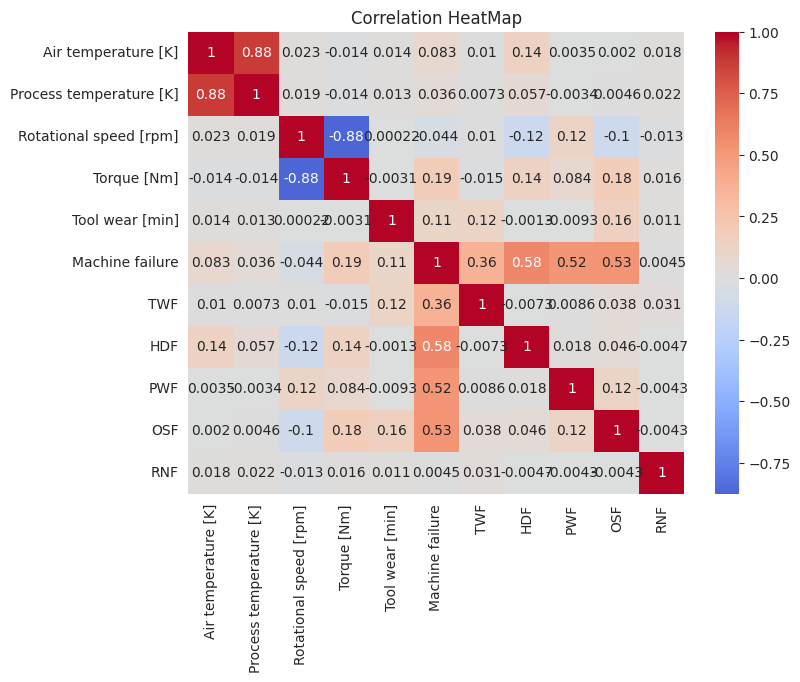

In [ ]:
# Correlation and HeatMap Graph
print("Correlation HeatMap")
corr_cols = numeric_cols + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix , annot=True , cmap = "coolwarm" , center=0)
plt.title('Correlation HeatMap')
plt.show()

Air temperature ↔ Process temperature::	0.8761 ::	Strong positive correlation
Rotational speed ↔ Torque	:: -0.8750	:: Strong negative correlation

Torque has the strongest positive correlation with machine failure, although the correlation is still relatively weak (0.191).
Tool wear also shows a weak positive relationship with failure (0.105).
Air temperature, process temperature, and rotational speed have very weak correlations with the target.

Machine failure ↔ HDF :: 0.58
Machine failure ↔ OSF :: 0.53
Machine failure ↔ PWF :: 0.52

Key Scatter Relationship


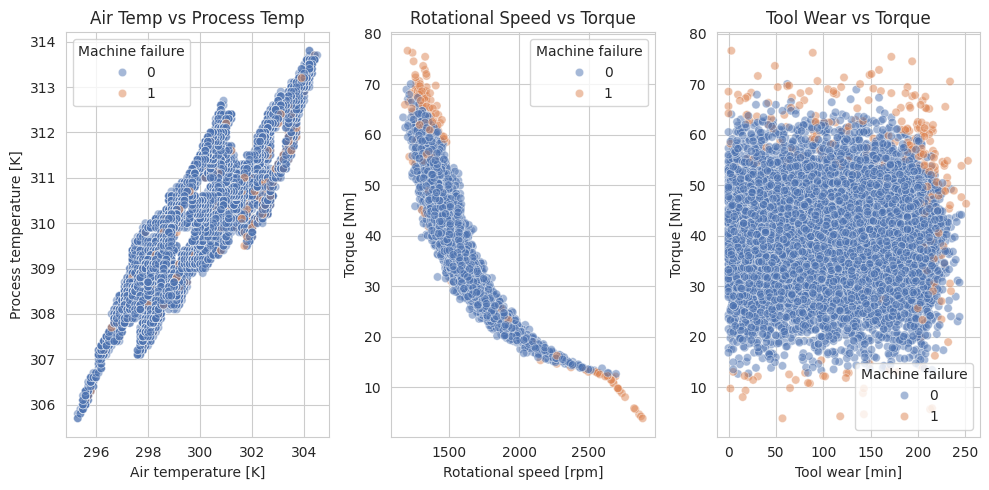

In [ ]:
#Key Relationships

print("Key Scatter Relationship")
fig , axes = plt.subplots(1,3 , figsize=(10,5))
sns.scatterplot(x='Air temperature [K]', y='Process temperature [K]', hue='Machine failure', data=df, alpha=0.5, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Air Temp vs Process Temp')
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', data=df, alpha=0.5, ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Rotational Speed vs Torque')
sns.scatterplot(x='Tool wear [min]', y='Torque [Nm]', hue='Machine failure', data=df, alpha=0.5, ax=axes[2], palette=['#4C72B0','#DD8452'])
axes[2].set_title('Tool Wear vs Torque')

plt.tight_layout()
plt.show()

1. Air Temperature vs Process Temperature :
The scatter plot shows a strong positive linear relationship between air temperature and process temperature.
2. Rotational Speed vs Torque :
There is a strong negative relationship between rotational speed and torque.
3. Tool Wear vs Torque :
The relationship between tool wear and torque is relatively weak, with no clear linear trend

Product Type Vs Failure Rate
Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64


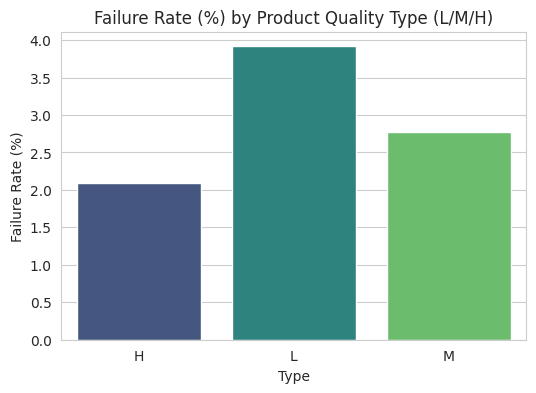

In [ ]:
print("Product Type Vs Failure Rate")
type_failure_rate = df.groupby('Type')['Machine failure'].mean() *100
print(type_failure_rate.round(2))

plt.figure(figsize=(6,4))
sns.barplot(x=type_failure_rate.index , y=type_failure_rate.values ,hue = type_failure_rate.index ,  palette = "viridis" , legend=False)
plt.title('Failure Rate (%) by Product Quality Type (L/M/H)')
plt.ylabel('Failure Rate (%)')
plt.show()

In [ ]:
print('--- STEP 4: PREPARE FEATURES & TARGET ---')

# 1. Encode the Categorical Column ('Type')
# We'll use pandas get_dummies for one-hot encoding.
# drop_first=True prevents the "dummy variable trap" by dropping one of the categories.
# dtype=int ensures the output is 0 and 1 instead of True and False.
print("\nEncoding the 'Type' column (L, M, H)...")
df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True, dtype=int)
print("Columns after one-hot encoding:\n", df_encoded.columns.tolist())

# 2. Define the Targets (y)
print("\nSeparating targets from features...")
# Binary target for initial modeling
y_binary = df_encoded['Machine failure']

# Multiclass/Multi-label targets for later experimentation
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
y_multi = df_encoded[failure_types]

# 3. Define the Features (X)

columns_to_drop = ['Machine failure'] + failure_types
X = df_encoded.drop(columns=columns_to_drop)

# 4. Verify the Splits
print('\n--- Feature Set (X) ---')
display(X.head())
print(f"Shape of X: {X.shape}")

print('\n--- Binary Target (y_binary) ---')
display(y_binary.head().to_frame())
print(f"Shape of y_binary: {y_binary.shape}")

print('\n--- Failure Type Targets (y_multi) ---')
display(y_multi.head())
print(f"Shape of y_multi: {y_multi.shape}")

--- STEP 4: PREPARE FEATURES & TARGET ---

Encoding the 'Type' column (L, M, H)...
Columns after one-hot encoding:
 ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']

Separating targets from features...

--- Feature Set (X) ---


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0


Shape of X: (10000, 7)

--- Binary Target (y_binary) ---


,Machine failure
0,0
1,0
2,0
3,0
4,0


Shape of y_binary: (10000,)

--- Failure Type Targets (y_multi) ---


,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


Shape of y_multi: (10000, 5)


In [ ]:
print('--- STEP 5: SPLIT THE DATA ---')

from sklearn.model_selection import train_test_split

# Splitting into training and testing sets (80% train, 20% test) for binary y
print("Splitting data into training and testing sets (80/20 split) with stratification...")
X_bi_train, X_bi_test, y_bi_train, y_bi_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)


# Verifying the shapes of the split datasets
print(f"\nShape of X_train: {X_bi_train.shape}")
print(f"Shape of y_train: {y_bi_train.shape}")
print(f"Shape of X_test: {X_bi_test.shape}")
print(f"Shape of y_test: {y_bi_test.shape}")


print("\nClass distribution in y_train:")
print(y_bi_train.value_counts(normalize=True).round(4))
print("\nClass distribution in y_test:")
print(y_bi_test.value_counts(normalize=True).round(4))

--- STEP 5: SPLIT THE DATA ---
Splitting data into training and testing sets (80/20 split) with stratification...

Shape of X_train: (8000, 7)
Shape of y_train: (8000,)
Shape of X_test: (2000, 7)
Shape of y_test: (2000,)

Class distribution in y_train:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Class distribution in y_test:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [ ]:
#Step 5b , Spilting for y_multi
print('STEP 5b: ALIGN y_multi TO THE SAME SPLIT')

y_multi_train = y_multi.loc[X_bi_train.index]
y_multi_test = y_multi.loc[X_bi_test.index]

assert (X_bi_train.index == y_multi_train.index).all()
assert (X_bi_test.index == y_multi_test.index).all()
print("y_multi aligned to Stage 1 split.")
print(f"y_multi_train shape: {y_multi_train.shape}")
print(f"y_multi_test shape: {y_multi_test.shape}")

STEP 5b: ALIGN y_multi TO THE SAME SPLIT
y_multi aligned to Stage 1 split.
y_multi_train shape: (8000, 5)
y_multi_test shape: (2000, 5)


In [ ]:
#Step 6a - SMOTE for Stage 1 (binary) , partial oversampling
from imblearn.over_sampling import SMOTE

# Check imbalance before
print("Before SMOTE — class distribution in y_bi_train:")
print(y_bi_train.value_counts())

#Applying SMOTE on training data
# Partial oversampling: minority class becomes 50% of majority class size
smote = SMOTE(random_state=42 , sampling_strategy=0.5)
X_bi_train_smote ,y_bi_train_smote = smote.fit_resample(X_bi_train , y_bi_train)
print("\nAfter SMOTE — class distribution in y_bi_train_smote:")
print(y_bi_train_smote.value_counts())
print(f"\nShape of X_bi_train_smote: {X_bi_train_smote.shape}")
print(f"Shape of y_bi_train_smote: {y_bi_train_smote.shape}")

Before SMOTE — class distribution in y_bi_train:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE — class distribution in y_bi_train_smote:
Machine failure
0    7729
1    3864
Name: count, dtype: int64

Shape of X_bi_train_smote: (11593, 7)
Shape of y_bi_train_smote: (11593,)


In [ ]:
#FEATURE SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_bi_train_scaled = scaler.fit_transform(X_bi_train_smote)

scaler = StandardScaler()

X_bi_train_scaled = scaler.fit_transform(X_bi_train_smote)
X_bi_test_scaled = scaler.transform(X_bi_test)

print(f"X_bi_train_scaled shape: {X_bi_train_scaled.shape}")
print(f"X_bi_test_scaled shape: {X_bi_test_scaled.shape}")

X_bi_train_scaled shape: (11593, 7)
X_bi_test_scaled shape: (2000, 7)


In [ ]:
#Data Prep for Stage 2 , y_multi , using the failure rows only from original dataset
#keeping only the rows with machine failure

# Filter using ORIGINAL (non-SMOTE) X_bi_train/y_bi_train — real failures only
failure_mask_train = y_bi_train == 1
X_stage2_train = X_bi_train[failure_mask_train]
y_multi_train_stage2 = y_multi_train[failure_mask_train]

failure_mask_test = y_bi_test == 1
X_stage2_test = X_bi_test[failure_mask_test]
y_multi_test_stage2 = y_multi_test[failure_mask_test]

In [ ]:
#Apply the SAME fitted scaler
X_stage2_train_scaled = scaler.transform(X_stage2_train)
X_stage2_test_scaled = scaler.transform(X_stage2_test)
print(f"\nX_stage2_train_scaled shape: {X_stage2_train_scaled.shape}")
print(f"X_stage2_test_scaled shape: {X_stage2_test_scaled.shape}")


X_stage2_train_scaled shape: (271, 7)
X_stage2_test_scaled shape: (68, 7)


In [ ]:
#to check whether stage 2 data need SMOTE or not
print(y_multi_train_stage2.sum())
print(y_multi_test_stage2['RNF'].sum())

TWF    36
HDF    86
PWF    82
OSF    82
RNF     1
dtype: int64
0


In [ ]:
print('--- STEP 7: TRAIN THE MODEL and compare ---')


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd



--- STEP 7: TRAIN THE MODEL and compare ---


In [ ]:
print('--- STEP 7: DETAILED COMPREHENSIVE K-FOLD CROSS-VALIDATION MATRIX ---')

import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import our 4 classifiers
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 4 Models
models = {
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. Set up Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to hold all structural fold data for our final formatted matrix DataFrame
matrix_data = {}

# 3. Manually loop through each model and each fold
for model_name, model_object in models.items():
    print(f"\n==================================================================")
    print(f" Evaluating Model: {model_name} across 5 Folds")
    print(f"==================================================================")

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []

    for fold_num, (train_index, val_index) in enumerate(skf.split(X_bi_train_scaled, y_bi_train_smote), 1):

        # Isolate this specific fold's training and validation slices
        X_fold_train, X_fold_val = X_bi_train_scaled[train_index], X_bi_train_scaled[val_index]
        y_fold_train, y_fold_val = y_bi_train_smote.iloc[train_index], y_bi_train_smote.iloc[val_index]

        # Clone the model architecture so it starts completely fresh for this fold
        fresh_model = clone(model_object)

        # Train on the 4 training folds
        fresh_model.fit(X_fold_train, y_fold_train)

        # Test on the 1 holdout validation fold
        predictions = fresh_model.predict(X_fold_val)

        # Calculate all 4 requested core metrics
        acc = accuracy_score(y_fold_val, predictions)
        prec = precision_score(y_fold_val, predictions, zero_division=0)
        rec = recall_score(y_fold_val, predictions, zero_division=0)
        f1 = f1_score(y_fold_val, predictions, zero_division=0)

        # Append scores to lists
        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_recalls.append(rec)
        fold_f1s.append(f1)

        print(f" -> Fold #{fold_num} | Acc: {acc*100:.1f}% | Prec: {prec*100:.1f}% | Rec: {rec*100:.1f}% | F1: {f1*100:.1f}%")

    # Save lists into our matrix tracker data dictionary using a multi-index key structure
    matrix_data[(model_name, 'Accuracy')] = fold_accuracies
    matrix_data[(model_name, 'Precision')] = fold_precisions
    matrix_data[(model_name, 'Recall')] = fold_recalls
    matrix_data[(model_name, 'F1-Score')] = fold_f1s

    # Print clean console summary for this specific model
    print(f"\n Summary for {model_name}:")
    print(f"   Average CV Accuracy : {np.mean(fold_accuracies) * 100:.2f}% (+/- {np.std(fold_accuracies) * 100:.2f}%)")
    print(f"   Average CV F1-Score : {np.mean(fold_f1s) * 100:.2f}% (+/- {np.std(fold_f1s) * 100:.2f}%)")

# 4. Construct a structured, multi-indexed academic matrix table
print("\n\n--- COMPLETE ACADEMIC CROSS-VALIDATION MATRIX ---")
# Convert dictionary to DataFrame and transpose so models are on rows
matrix_df = pd.DataFrame(matrix_data).T
matrix_df.columns = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# Assign descriptive names to our MultiIndex levels
matrix_df.index.names = ['Model', 'Metric']

# Calculate the mean and standard deviation across columns (axis=1) for all 4 metrics
matrix_df['Mean CV Score'] = matrix_df.mean(axis=1)
matrix_df['Standard Deviation'] = matrix_df.std(axis=1)

# Format the entire structured table as percentages for presentation
display(matrix_df.style.format(lambda x: f"{x*100:.2f}%"))

--- STEP 7: DETAILED COMPREHENSIVE K-FOLD CROSS-VALIDATION MATRIX ---

 Evaluating Model: XGBoost across 5 Folds
 -> Fold #1 | Acc: 98.1% | Prec: 96.3% | Rec: 98.2% | F1: 97.2%
 -> Fold #2 | Acc: 97.8% | Prec: 96.1% | Rec: 97.5% | F1: 96.8%
 -> Fold #3 | Acc: 98.4% | Prec: 96.8% | Rec: 98.4% | F1: 97.6%
 -> Fold #4 | Acc: 98.5% | Prec: 97.9% | Rec: 97.5% | F1: 97.7%
 -> Fold #5 | Acc: 98.1% | Prec: 96.5% | Rec: 97.7% | F1: 97.1%

 Summary for XGBoost:
   Average CV Accuracy : 98.19% (+/- 0.23%)
   Average CV F1-Score : 97.30% (+/- 0.34%)

 Evaluating Model: KNN across 5 Folds
 -> Fold #1 | Acc: 95.7% | Prec: 90.0% | Rec: 97.9% | F1: 93.8%
 -> Fold #2 | Acc: 94.3% | Prec: 88.1% | Rec: 95.9% | F1: 91.8%
 -> Fold #3 | Acc: 95.0% | Prec: 89.3% | Rec: 96.4% | F1: 92.7%
 -> Fold #4 | Acc: 96.0% | Prec: 91.3% | Rec: 97.4% | F1: 94.2%
 -> Fold #5 | Acc: 95.7% | Prec: 91.2% | Rec: 96.5% | F1: 93.8%

 Summary for KNN:
   Average CV Accuracy : 95.34% (+/- 0.63%)
   Average CV F1-Score : 93.27% (+

In [ ]:
#step 7 but here we are predicting what kind of error occurs in case of failiure
print("Initializing Multi-Output Classifiers for maintenance type prediction...")
from sklearn.multioutput import MultiOutputClassifier
stage2_models = {
    "XGBoost": MultiOutputClassifier(xgb.XGBClassifier(random_state=42, eval_metric='logloss')),
    "KNN": MultiOutputClassifier(KNeighborsClassifier(n_neighbors=3)),
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(random_state=42))
}

stage2_results = []
failure_type_names = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


for name, model in stage2_models.items():
    print(f"\nTraining {name} on breakdown historical data...")

    # Train using ONLY the rows where a machine actually failed
    model.fit(X_stage2_train_scaled, y_multi_train_stage2)

    # Predict failure types on the test set failures
    y_pred_stage2 = model.predict(X_stage2_test_scaled)

    # Calculate Exact Match Accuracy (Subset Accuracy)
    # This means the model must get ALL 5 failure types right for a row to count as correct
    exact_match_acc = accuracy_score(y_multi_test_stage2, y_pred_stage2)

    stage2_results.append({
        "Model": name,
        "Exact Match Accuracy": f"{exact_match_acc * 100:.2f}%"
    })

    print(f"\n--- Detailed Classification Report for {name} ---")
    print(classification_report(y_multi_test_stage2, y_pred_stage2, target_names=failure_type_names, zero_division=0))

print("\n=== STAGE 2: MAINTENANCE TYPE PREDICTION COMPARISON ===")
stage2_df = pd.DataFrame(stage2_results)
display(stage2_df)

Initializing Multi-Output Classifiers for maintenance type prediction...

Training XGBoost on breakdown historical data...

--- Detailed Classification Report for XGBoost ---
              precision    recall  f1-score   support

         TWF       0.71      0.50      0.59        10
         HDF       0.96      0.90      0.93        29
         PWF       0.87      1.00      0.93        13
         OSF       0.84      1.00      0.91        16
         RNF       0.00      0.00      0.00         0

   micro avg       0.88      0.88      0.88        68
   macro avg       0.68      0.68      0.67        68
weighted avg       0.88      0.88      0.88        68
 samples avg       0.82      0.86      0.83        68


Training KNN on breakdown historical data...

--- Detailed Classification Report for KNN ---
              precision    recall  f1-score   support

         TWF       0.78      0.70      0.74        10
         HDF       0.96      0.90      0.93        29
         PWF       0.80  

,Model,Exact Match Accuracy
0,XGBoost,77.94%
1,KNN,82.35%
2,Logistic Regression,86.76%
3,Random Forest,85.29%


In [ ]:
print('--- STEP 8: HYPERPARAMETER TUNING ---')

# 1) Hypertune binary for XGBoost model
print('\n--- 1. Hyperparameter Tuning for XGBoost (Binary Classification) ---')

# Define the parameter grid for XGBoost
binary_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize GridSearchCV for XGBoost
grid_search_xgb_binary = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=binary_param_grid,
    scoring='f1', # Use f1-score as it's a good metric for imbalanced datasets
    cv=3, # Using 3-fold cross-validation for speed, can be increased to 5 or more
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("Fitting GridSearchCV for XGBoost (binary)...")
grid_search_xgb_binary.fit(X_bi_train_scaled, y_bi_train_smote)

print("\nBest parameters for XGBoost (binary):", grid_search_xgb_binary.best_params_)
print("Best F1-score for XGBoost (binary) during CV:", grid_search_xgb_binary.best_score_)

# Evaluate the best binary XGBoost model on the test set
best_xgb_binary_model = grid_search_xgb_binary.best_estimator_
y_pred_xgb_binary = best_xgb_binary_model.predict(X_bi_test_scaled)

print("\n--- Classification Report for Tuned XGBoost (Binary) on Test Set ---")
print(classification_report(y_bi_test, y_pred_xgb_binary, zero_division=0))

# 2) Hypertune multi for Logistic Regression model
print('\n--- 2. Hyperparameter Tuning for Logistic Regression (Multi-Output) ---')

# Define the parameter grid for Logistic Regression inside MultiOutputClassifier
# Modified to use only 'l2' penalty to avoid ValueError with single-class folds
multi_lr_param_grid = {
    'estimator__C': [0.01, 0.1, 1, 10],
    'estimator__penalty': ['l2'], # Changed from ['l1', 'l2'] to ['l2']
    'estimator__solver': ['liblinear']
}

# Initialize GridSearchCV for MultiOutputClassifier with LogisticRegression
grid_search_multi_lr = GridSearchCV(
    estimator=MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)),
    param_grid=multi_lr_param_grid,
    scoring='f1_micro', # Micro F1-score for multi-label classification
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Fitting GridSearchCV for Multi-Output Logistic Regression...")
grid_search_multi_lr.fit(X_stage2_train_scaled, y_multi_train_stage2)

print("\nBest parameters for Multi-Output Logistic Regression:", grid_search_multi_lr.best_params_)
print("Best F1-micro score for Multi-Output Logistic Regression during CV:", grid_search_multi_lr.best_score_)

# Evaluate the best multi-output Logistic Regression model on the test set
best_multi_lr_model = grid_search_multi_lr.best_estimator_
y_pred_multi_lr = best_multi_lr_model.predict(X_stage2_test_scaled)

print("\n--- Classification Report for Tuned Multi-Output Logistic Regression on Test Set ---")
failure_type_names = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'] # Re-define for clarity
print(classification_report(y_multi_test_stage2, y_pred_multi_lr, target_names=failure_type_names, zero_division=0))

exact_match_acc_tuned_lr = accuracy_score(y_multi_test_stage2, y_pred_multi_lr)
print(f"\nExact Match Accuracy for Tuned Multi-Output Logistic Regression: {exact_match_acc_tuned_lr * 100:.2f}%")

--- STEP 8: HYPERPARAMETER TUNING ---

--- 1. Hyperparameter Tuning for XGBoost (Binary Classification) ---
Fitting GridSearchCV for XGBoost (binary)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters for XGBoost (binary): {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best F1-score for XGBoost (binary) during CV: 0.9703905762204673

--- Classification Report for Tuned XGBoost (Binary) on Test Set ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.62      0.79      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.98      0.98      0.98      2000


--- 2. Hyperparameter Tuning for Logistic Regression (Multi-Output) ---
Fitting GridSearchCV for Multi-Output Logistic Regression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters for Multi-Outp

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/multioutput.py", line 543, in fit
    super().fit(X, Y, sample_weight=sample_weight, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^